# 03 · Diagnosis — which fault is active, and what drives it?

Detection answers *is something wrong?*. Diagnosis answers *what specifically?*. We use XGBoost on per-sensor summary features and explain it with SHAP.

In [1]:
import sensorlab  # set OMP env vars before torch/xgboost load
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline
plt.rcParams.update({"figure.dpi": 110, "figure.figsize": (9, 4)})


In [2]:
from sensorlab.data import (load_dataset, SyntheticTEPConfig, Standardizer,
                           sliding_windows, train_val_test_split_by_run)
from sensorlab.diagnosis import (FaultClassifier, window_features,
                                explain_classifier, top_sensors_per_fault)

cfg = SyntheticTEPConfig(n_normal_runs=12, n_runs_per_fault=4, fault_run_minutes=480, seed=0)
ds = load_dataset("synthetic", cfg=cfg)
train_m, val_m, test_m = train_val_test_split_by_run(ds, seed=0)
sc = Standardizer.fit(ds.X[train_m & (ds.fault_id == 0)])
Xz = sc.transform(ds.X)
windows, _, end_idx = sliding_windows(Xz, ds.run_id, window=20, stride=2)
feats, fnames = window_features(windows, ds.sensor_names)
labels = ds.fault_id[end_idx]; in_train = train_m[end_idx]; in_test = test_m[end_idx]

## Train

In [3]:
clf = FaultClassifier(n_estimators=300, max_depth=6).fit(feats[in_train], labels[in_train],
                                                        feature_names=fnames)
preds = clf.predict(feats[in_test])
from sklearn.metrics import f1_score, accuracy_score, confusion_matrix
print(f"accuracy:  {accuracy_score(labels[in_test], preds):.3f}")
print(f"macro-F1:  {f1_score(labels[in_test], preds, average='macro'):.3f}")

accuracy:  0.568
macro-F1:  0.577


## Confusion matrix

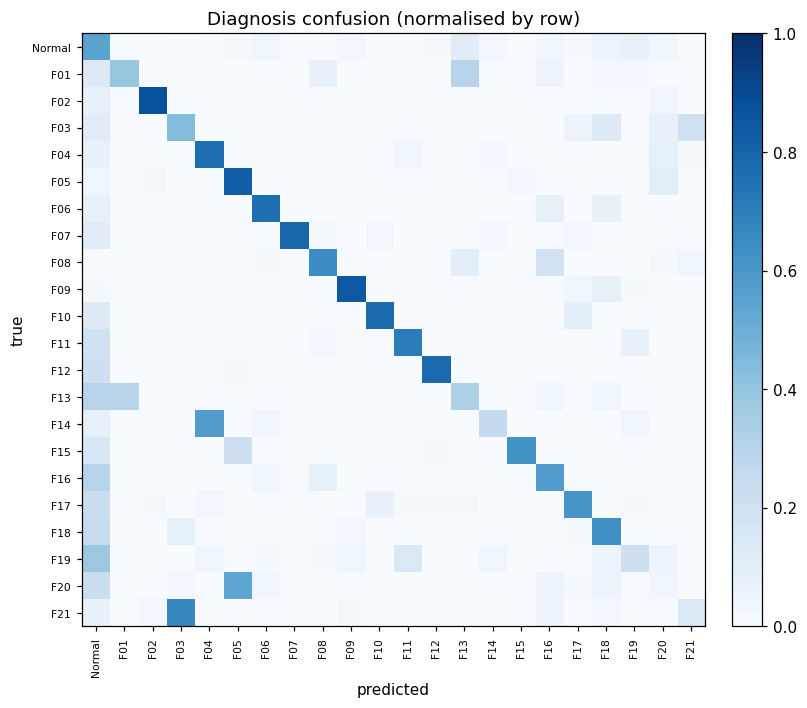

In [4]:
from sensorlab.viz import plot_confusion_matrix
cm = confusion_matrix(labels[in_test], preds, labels=np.arange(22))
fig, ax = plt.subplots(figsize=(8, 7))
plot_confusion_matrix(cm, [f"F{i:02d}" if i > 0 else "Normal" for i in range(22)], ax=ax)
ax.set_title("Diagnosis confusion (normalised by row)")
plt.show()

## SHAP — which sensor drives each fault?

The value of a model isn't only its accuracy — it's whether a process engineer can trust the *reason* it gave.

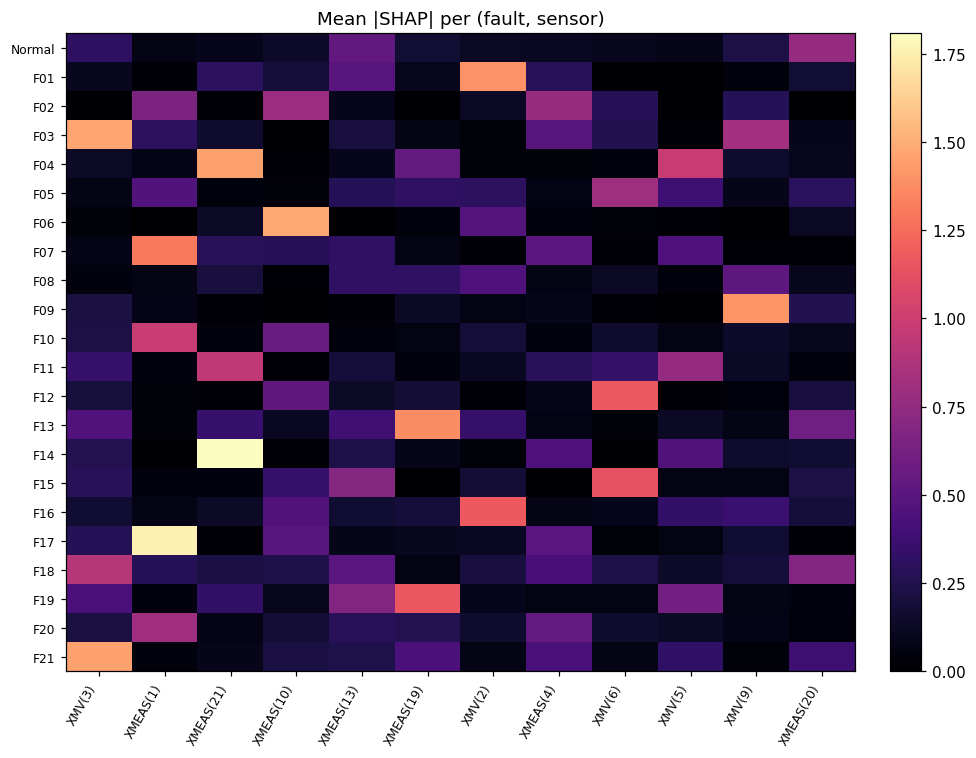

In [5]:
rep = explain_classifier(clf, feats[in_test][:500], fnames, ds.sensor_names, max_background=300)
from sensorlab.viz import plot_shap_summary
fig, ax = plt.subplots(figsize=(9, 7))
plot_shap_summary(rep.per_sensor_class_importance, ds.sensor_names, rep.class_ids,
                  top_k=12, ax=ax)
plt.tight_layout(); plt.show()

In [6]:
# The top 3 driver sensors for each fault, ranked by mean |SHAP|
tops = top_sensors_per_fault(rep, k=3)
for fid in sorted(tops.keys())[:8]:
    names = ", ".join(f"{s} ({v:.2f})" for s, v in tops[fid])
    print(f"F{fid:02d}:  {names}")

F01:  XMV(2) (1.40), XMEAS(2) (0.61), XMV(11) (0.58)
F02:  XMV(10) (0.94), XMEAS(10) (0.79), XMEAS(4) (0.78)
F03:  XMV(3) (1.48), XMV(9) (0.83), XMV(1) (0.74)
F04:  XMEAS(21) (1.45), XMV(5) (0.98), XMEAS(19) (0.55)
F05:  XMEAS(5) (0.90), XMV(6) (0.80), XMEAS(9) (0.68)
F06:  XMEAS(10) (1.48), XMEAS(18) (0.75), XMV(2) (0.48)
F07:  XMEAS(1) (1.31), XMV(1) (0.79), XMEAS(4) (0.50)
F08:  XMEAS(18) (1.07), XMV(9) (0.51), XMV(11) (0.45)


**Takeaways**

- Step / drift faults are diagnosed reliably; noise-increase and intermittent faults are harder (they overlap in sensor signature).
- SHAP gives a single sensor (or two) per fault — actionable for a process engineer.
- A future improvement: a hierarchical classifier (fault family first, then sub-type) for the harder pairs.